## 超导元素周期表

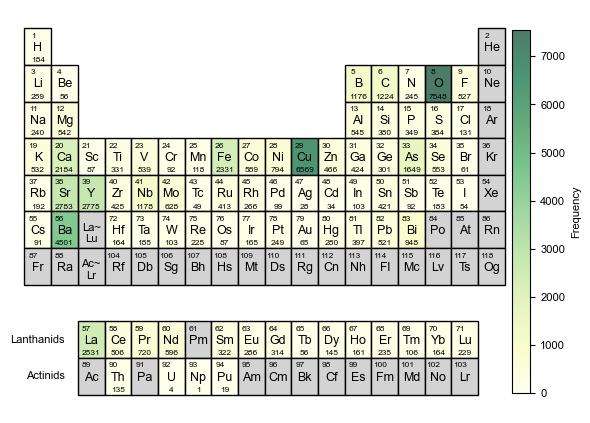

In [7]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize, LinearSegmentedColormap
import pandas as pd
import re
from mendeleev import get_all_elements
import numpy as np
import csv

# 化学式拆分为字典
def parse_formula(formula):
    formula = str(formula)  # 确保formula是字符串
    elements_ratios = {}
    for element, ratio in re.findall(r'([A-Z][a-z]*)(\d*\.?\d*)', formula):
        if element in elements_ratios:
            elements_ratios[element] += float(ratio) if ratio else 1
        else:
            elements_ratios[element] = float(ratio) if ratio else 1
    return elements_ratios

# 数据预处理：统计元素频数
def preprocess_molecular_data(data, Tc_line=5):
    element_counts = {}
    for index, row in data.iterrows():  # 使用iterrows()遍历DataFrame
        if row['Tc'] > Tc_line:  # 直接使用行数据访问Tc
            for element in parse_formula(row['formula']):
                element_counts[element] = element_counts.get(element, 0) + 1
    return element_counts         

# 绘制单个元素
def plot_element(ax, x, y, symbol, atomic_num, frequency, color_map, normalize):
    symb_fs = 9; # 元素符号大小
    num_fs = 6 # 元素序号大小
    Fre_fs = 6 # 频率次数大小
    color = color_map(normalize(frequency)) if frequency else 'lightgrey'
    ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, facecolor=color, edgecolor='black'))#设置边框
    ax.text(x, y + 0.03, symbol, fontsize=symb_fs, ha='center', va='center', color='black')
    ax.text(x - 0.18, y - 0.3, f'{atomic_num}', fontsize=num_fs, ha='center', va='center', color='black')

    if frequency:
        ax.text(x, y + 0.37, f'{frequency}', fontsize=Fre_fs, ha='center', va='center', color='black')
# 绘制周期表元素
def plot_elements(ax, elements, element_counts, lanthanoid, actinoid, color_map, normalize):
    for el in elements:
        if el.symbol in lanthanoid:
            x, y = 3 + lanthanoid.index(el.symbol), 9
        elif el.symbol in actinoid:
            x, y = 3 + actinoid.index(el.symbol), 10
        else:
            x, y = el.group_id, el.period
        plot_element(ax, x, y, el.symbol, el.atomic_number, element_counts.get(el.symbol, 0), color_map, normalize)

# 绘制镧系和锕系范围
def plot_lanthanoid_actinoid_labels(ax):
    """绘制镧系和锕系元素的范围"""
    # 镧系和锕系元素特殊处理
    ax.text(2, 9, "Lanthanids", fontsize=8, ha='right', va='center', color='black')
    ax.text(2, 10, "Actinids", fontsize=8, ha='right', va='center', color='black')
    bg_color = 'lightgrey'
    # # 镧系元素
    ax.text(3, 6+0.1, 'La~\nLu', fontsize=8, ha='center', va='center', color='black')
    # ax.text(3 - 0.05, 6 - 0.3, '57~71', fontsize=8, ha='center', va='center', color='black')
    ax.add_patch(plt.Rectangle((3 - 0.5, 6 - 0.5), 1, 1, facecolor=bg_color, edgecolor='black'))
    
    # # 锕系元素
    ax.text(3, 7+0.1, 'Ac~\nLr', fontsize=8, ha='center', va='center', color='black')
    # ax.text(3 - 0.05, 7 - 0.3, '89~103', fontsize=8, ha='center', va='center', color='black')
    ax.add_patch(plt.Rectangle((3 - 0.5, 7 - 0.5), 1, 1, facecolor=bg_color, edgecolor='black'))

# 主函数：绘制周期表
def main(Tc_line=5):
    # 读取数据并统计频数
    df = pd.read_csv(DATA_PATH, low_memory=False)
    element_counts = preprocess_molecular_data(df,Tc_line)

    lanthanoid = ['La', 'Ce', 'Pr', 'Nd', 'Pm', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu']
    actinoid = ['Ac', 'Th', 'Pa', 'U', 'Np', 'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md', 'No', 'Lr']

    max_freq = max(element_counts.values(), default=1)
    normalize = Normalize(vmin=0, vmax=max_freq)

    # 初始化绘图
    fig_height = 11  # cm
    fig_width = 16  # cm
    plt.rcParams['font.family'] = 'Arial'  # 例如，设置为 Arial 字体
    fig, ax = plt.subplots(figsize=(fig_width / 2.54, fig_height / 2.54))
    # 绘制元素和镧系/锕系标签
    plot_lanthanoid_actinoid_labels(ax)
    plot_elements(ax, elements, element_counts, lanthanoid, actinoid, color_map, normalize)
    # 图表设置
    ax.set_xlim(0, 19)
    ax.set_ylim(0, 11)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.axis('off')  # 隐藏整个坐标轴框架
    
    # 添加颜色条
    cbar = fig.colorbar(cm.ScalarMappable(norm=normalize, cmap=color_map), ax=ax, orientation='vertical',pad=-0.01,shrink=0.9)
    cbar.set_label('Frequency', fontsize=8)

    cbar.ax.tick_params(labelsize=8)  # 设置刻度标签的字体大小
    # 调整布局
    plt.tight_layout()
    # 显示图表
    plt.savefig('./Pic/Fig2c_a4.svg', bbox_inches='tight',transparent=True)
    plt.savefig('./Pic/Fig2c_a4.tif', dpi=600, bbox_inches='tight',transparent=True)
    plt.show()

    # # 检查无效元素符号
    # invalid_symbols = set(element_counts.keys()) - {el.symbol for el in elements}
    # if invalid_symbols:
    #     print("Invalid element symbols found:", invalid_symbols)
    # else:
    #     print("All element symbols are valid.")
    # print(element_counts)

    # 元素数量统计
    # with open('alloyelement.csv', 'w', newline='', encoding='utf-8') as csvfile:
    # # 指定字段名
    #     fieldnames = ['Element', 'Count']
    
    # # 创建一个csv.writer对象
    #     writer = csv.writer(csvfile)
    
    # # 写入表头
    #     writer.writerow(fieldnames)
    
    # # 写入数据
    #     for element, count in element_counts.items():
    #         writer.writerow([element, count])

# 运行主函数
if __name__ == "__main__":
    # 数据路径
    DATA_PATH = '../Data/mdr_clean.csv'
    # 获取周期表元素
    elements = get_all_elements()
    # 调节color_map的RGB values
    original_cmap = cm.YlGn  # 预定义
    colors = original_cmap(np.linspace(0, 1, original_cmap.N))  # 获取颜色
    colors[:, -1] = colors[:, -1] * 0.7  # -1是透明度。前面的行都是RGB色值
    color_map = LinearSegmentedColormap.from_list("lighter_YlOrBr", colors)
    main(Tc_line=5)


# 二元合金超导温度作图

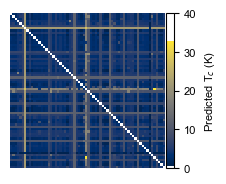

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import defaultdict
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

DATA_PATH = '../Code/4_alloy_predict/2Alloy_rf.csv'
# 从CSV文件中读取数据
df = pd.read_csv(DATA_PATH, low_memory=False)

# 提取所有元素名称作为x轴和y轴标签
x_labels = []
y_labels = []
for _, row in df.iterrows():
    x, y = row['elements'].split('-')
    x_labels.append(x)
    y_labels.append(y)

# 存储Tc值
tc_values = defaultdict(lambda: defaultdict(float))
for i, (x, y) in enumerate(zip(x_labels, y_labels)):
    tc_values[x][y] = round(df.loc[i, 'Predicted_Tc'], 2)  # 保留两位小数
    tc_values[y][x] = round(df.loc[i, 'Predicted_Tc'], 2)  # 保留两位小数

# 将字典转换为numpy数组，用于绘图
element_unique = sorted(list(tc_values.keys()))
n_ele = len(element_unique)

# 创建一个空的矩阵，用于存储Tc值
matrix = np.full((n_ele, n_ele), np.nan)

# 填充矩阵的非对角线位置
for i, x in enumerate(element_unique):
    for j, y in enumerate(element_unique):
        if i!=j:
            matrix[i, j] = tc_values[x][y]


# 创建热力图
fig_height = 6 #cm
fig_width = 6 #cm
# 初始化绘图
plt.rcParams['font.family'] = 'Arial'  # 例如，设置为 Arial 字体
plt.figure(figsize=(fig_width/2.54, fig_height/2.54))
heatmap = plt.imshow(matrix, cmap='cividis', interpolation='none')

f_size = 8
# 添加颜色条
cbar = plt.colorbar(heatmap,orientation='vertical',pad=0.01,shrink=0.75)  # 调整颜色条距离
cbar.set_ticks(np.arange(0, 41, 10))
cbar.set_label('Predicted T$_c$ (K)', fontsize=f_size)
cbar.ax.tick_params(labelsize=f_size)  # 设置刻度标签的字体大小

# # 设置图表标题和坐标轴标签
# plt.xlabel('Elements', fontsize=f_size)
# plt.ylabel('Elements', fontsize=f_size)

# # 设置横纵坐标刻度
# plt.xticks(range(n_ele), element_unique, rotation=89, fontsize=12)
# plt.yticks(range(n_ele), element_unique, fontsize=12)
plt.axis('off')


# 调整图表边距
plt.tight_layout()

# 显示图表
plt.savefig('./Pic/Fig4d_2_a4.svg', bbox_inches='tight',transparent=True)
plt.savefig('./Pic/Fig4d_2_a4.tif', dpi=600, bbox_inches='tight',transparent=True)
plt.show()

# 数据量对预测搜寻的影响

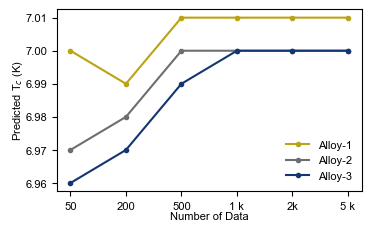

In [3]:
import matplotlib.pyplot as plt

data_num = ['5 k', '2k', '1 k', '500', '200', '50']
alloys_data = {
    'Alloy-1': [
        'In0.500Sn0.500', 'In0.487Sn0.494Zn0.019', 'In0.500Sn0.500', 
        'In0.500Sn0.500', 'In0.500Sn0.500', 'In0.500Sn0.500', 'In0.506Sn0.494', 
        'In0.502Sn0.498'
    ],
    'Alloy-2': [
        'Ga0.002In0.596Sn0.402', 'In0.500Sn0.500', 'In0.501Sn0.499', 
        'In0.501Sn0.499', 'In0.501Sn0.499', 'In0.502Sn0.498', 'In0.498Sn0.502', 
        'In0.508Sn0.492'
    ],
    'Alloy-3': [
        'Bi0.005In0.592Sn0.403', 'In0.499Sn0.497Ag0.004', 'In0.486Sn0.494Zn0.020', 
        'In0.502Sn0.498', 'In0.502Sn0.498', 'In0.499Sn0.501', 'In0.496Sn0.504', 
        'In0.490Sn0.502Zn0.008'
    ],
}
tc_values = {
    'Alloy-1': [7.01, 7.01, 7.01, 7.01, 6.99, 7.00],
    'Alloy-2': [7.00, 7.00, 7.00, 7.00, 6.98, 6.97],
    'Alloy-3': [7.00, 7.00, 7.00, 6.99, 6.97, 6.96]
}
# 指定颜色
colors = [ '#BBA315','#6C6E72','#143670']

# 创建折线图
fig_height = 6 #cm
fig_width = 10 #cm
# 初始化绘图
plt.rcParams['font.family'] = 'Arial'  # 例如，设置为 Arial 字体
plt.figure(figsize=(fig_width/2.54, fig_height/2.54))

# 反转数据顺序
data_num_reversed = data_num[::-1]
tc_values_reversed = {alloy: tc_values[alloy][::-1] for alloy in tc_values}

# 绘制每条折线图，并指定颜色
for alloy, color in zip(alloys_data.keys(), colors):
    plt.plot(data_num_reversed, tc_values_reversed[alloy], label=alloy, marker='o', color=color,markersize=3)

# 添加标题和标签
plt.xlabel('Number of Data', color='black', fontsize=8, labelpad=0)
plt.ylabel('Predicted T$_c$ (K)', color='black', fontsize=8, labelpad=0)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

# 添加图例
plt.legend(fontsize=8, framealpha=0)
# 显示图表
plt.savefig('./Pic/Fig4b_a4.svg', bbox_inches='tight', transparent=True)
plt.savefig('./Pic/Fig4b_a4.tif', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

# 三元超导温度作图

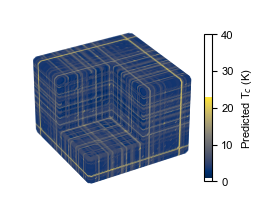

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from collections import defaultdict
import matplotlib.cm as cm

# 读取CSV文件
DATA_PATH = '../Code/4_alloy_predict/3Alloy_et.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)

# 提取所有元素名称
e1_labels = []
e2_labels = []
e3_labels = []
for _, row in df.iterrows():
    e1, e2, e3 = row['elements'].split('-')
    e1_labels.append(e1)
    e2_labels.append(e2)
    e3_labels.append(e3)

# 存储Tc值
tc_values = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))
for i, (e1, e2, e3) in enumerate(zip(e1_labels, e2_labels, e3_labels)):
    tc_value = round(df.loc[i, 'Predicted_Tc'], 2)
    tc_values[e1][e2][e3] = tc_value
    tc_values[e1][e3][e2] = tc_value
    tc_values[e2][e1][e3] = tc_value
    tc_values[e2][e3][e1] = tc_value
    tc_values[e3][e1][e2] = tc_value
    tc_values[e3][e2][e1] = tc_value

# 去重并排序元素名称
unique_elements = sorted(set(e1_labels + e2_labels + e3_labels))
element_to_index = {e: i for i, e in enumerate(unique_elements)}
n_ele = len(unique_elements)

# 构建坐标
x, y, z, tc_vals = [], [], [], []
for e1, nested1 in tc_values.items():
    for e2, nested2 in nested1.items():
        for e3, tc in nested2.items():
            if e1 in element_to_index and e2 in element_to_index and e3 in element_to_index:
                # 将元素映射到坐标轴 (0-65)
                x.append(element_to_index[e1])
                y.append(element_to_index[e2])
                z.append(element_to_index[e3])
                tc_vals.append(tc)

x = np.array(x)
y = np.array(y)
z = np.array(z)
tc_vals = np.array(tc_vals)

mask = (x <= 30) | (y <= 30) | (z <= 20)
x_masked = x[mask]
y_masked = y[mask]
z_masked = z[mask]
tc_vals_masked = tc_vals[mask]

# 创建3D散点图
fig_height = 7 #cm
fig_width = 7 #cm
# 初始化绘图
plt.rcParams['font.family'] = 'Arial'  # 例如，设置为 Arial 字体
fig = plt.figure(figsize=(fig_width/2.54, fig_height/2.54))
ax = fig.add_subplot(111, projection='3d')
# original_cmap = cm.turbo  # 预定义
# colors = original_cmap(np.linspace(0, 1, original_cmap.N))  # 获取颜色
# colors[:, -1] = colors[:, -1] * 0.95  # -1是透明度。前面的行都是RGB色值
# colors[:, :3] *= 0.9 # 降低亮度
# color_map = LinearSegmentedColormap.from_list("user", colors)
# color_map.set_bad(color='none')  # 设置 nan 值为透明
# 绘制剖切后的散点图
sc = ax.scatter(x_masked, y_masked, z_masked, c=tc_vals_masked, cmap='cividis', s=5)

# 添加颜色条
f_size = 8
cbar = plt.colorbar(sc, orientation='vertical', pad=-0.01, shrink=0.6)
cbar.set_ticks(np.arange(0, 41, 10))
cbar.set_label('Predicted T$_c$ (K)', fontsize=f_size)
cbar.ax.tick_params(labelsize=f_size)  # 设置刻度标签的字体大小

# 设置视角和标签
ax.view_init(elev=30, azim=60)  # 旋转角度
# ax.set_xticks(range(n_ele))
# ax.set_xticklabels(unique_elements, fontsize=12)
# ax.set_yticks(range(n_ele))
# ax.set_yticklabels(unique_elements, fontsize=12)
# ax.set_zticks(range(n_ele))
# ax.set_zticklabels(unique_elements, fontsize=12)
# ax.set_xlabel('Element 1')
# ax.set_ylabel('Element 2')
# ax.set_zlabel('Element 3',rotation=90)
plt.axis('off')
# 调整图表边距
plt.tight_layout()
plt.savefig('./Pic/Fig4c_3_a4.svg', bbox_inches='tight',transparent=True)
plt.savefig('./Pic/Fig4c_3_a4.tif', dpi=600, bbox_inches='tight',transparent=True)
plt.show()
